In [1]:
%load_ext autoreload
%autoreload 2

%matplotlib inline

import numpy as np

import sys
sys.path.insert(0, "/zhome/71/c/146676/texture_tomography/maptools")
import maptools

print(maptools.__file__)
print(maptools.__path__)
import os

import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from multiprocessing import Pool
from datetime import datetime
from tqdm.notebook import tqdm


import matplotlib
from scipy.spatial import cKDTree as KDTree


/zhome/71/c/146676/texture_tomography/maptools/maptools/__init__.py
['/zhome/71/c/146676/texture_tomography/maptools/maptools']


In [2]:
maptools.job.info()
maptools.plot.dark()
!which python
from scipy.ndimage import generic_filter
from scipy.optimize import curve_fit
from matplotlib.patches import FancyArrowPatch, Circle


from ImageD11 import cImageD11
from ImageD11.sinograms.roi_iradon import run_iradon, run_mlem
from scipy.ndimage import (
    gaussian_filter,
    median_filter,
    maximum_filter,
    binary_fill_holes,
)

from orix import plot
from orix.vector import Vector3d, Miller
from orix.quaternion.symmetry import Oh
from orix.quaternion import Orientation, symmetry
from orix.crystal_map import Phase

from scipy.ndimage import rotate

import time
import numba
import ImageD11.columnfile
import ImageD11.sinograms.dataset
import ImageD11.sinograms.geometry as geometry
import ImageD11.sinograms.point_by_point
import ImageD11.sinograms.point_by_point as pbp
from ImageD11.nbGui import nb_utils as utils

hostname: n-62-20-9
SLURM_JOB_ID: None
SLURM_JOB_NODELIST: None
NPROCS: 32
Memory available: 399.036428288 GB
~/miniconda3/envs/textom/bin/python


In [3]:
import h5py

path = os.path.join(maptools.paths.RAW, "al1050_15pct_center_slice", "scan-0042.h5")

with h5py.File(path, "r") as f:
    print(f['entry/title'][()])


b'meshct_maxiv tom_ry 0.0 360.3 3604 im_x -0.75 -0.62 13 0.099 False 0.001'


In [5]:
root = "/dtu/3d-imaging-center/projects/2025_QIM_BlackBeauty/raw_data_extern/2025_Danmax_Al1050/process/al1050_15pct_center_slice"
recpath = os.path.join(
    maptools.paths.PROCESS, "al1050_15pct_center_slice", "reconstructions"
)
filetag = "medium_pks_18M_2025_1213_095603"
# dset_path = os.path.join(root, filetag + "_dummy_dset.h5")
# colf_path = os.path.join(root, filetag + "_colf.h5")

# y0 = maptools.constants.ROTATION_AXIS_DTY_SHIFT
# colf = ImageD11.columnfile.colfile_from_hdf(colf_path)

In [6]:
d = maptools.io.load_analysis_bundle(recpath, filetag)

orix_orien = d["orientation_orix"]
grains = d["grains_raw"]
index = d["filter_index"]

rgb_filtered = d["rgb_map_filtered"]
ubi_filtered = d["ubi_map_filtered"]
nuniq_filtered = d["nuniq_map_filtered"]
eps_filtered = d["strain_map_filtered"]

gmap = d["g_map_raw"]
rgbmap = d["rgb_map_raw"]
unimap = d["uniqueness_map_raw"]
epsmap = d["strain_map_raw"]

orientation_map = d["orientation_map_filtered"]
kam = d["kam_map_filtered"]

sample_mask = m = d["sample_mask"]
rec = d["reconstruction_mlem"]


FileNotFoundError: [Errno 2] No such file or directory: '/dtu/3d-imaging-center/projects/2025_QIM_BlackBeauty/raw_data_extern/2025_Danmax_Al1050/process/al1050_15pct_center_slice/reconstructions/medium_pks_18M_2025_1213_095603/medium_pks_18M_2025_1213_095603.pkl'

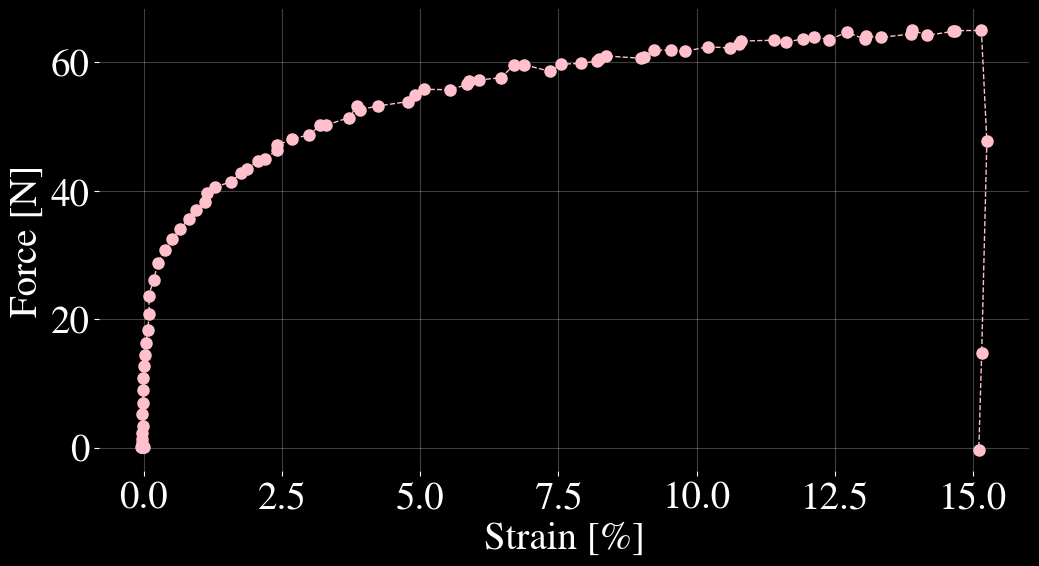

In [39]:
strain, force = maptools.io.load_strain_and_force()
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
ax.plot(strain * 100, force, "--o", c="pink", linewidth=1, markersize=8)
ax.grid(True, alpha=0.25)
ax.set_xlabel("Strain [%]")
ax.set_ylabel("Force [N]")
for spine in ax.spines.values():
    spine.set_visible(False)
plt.show()

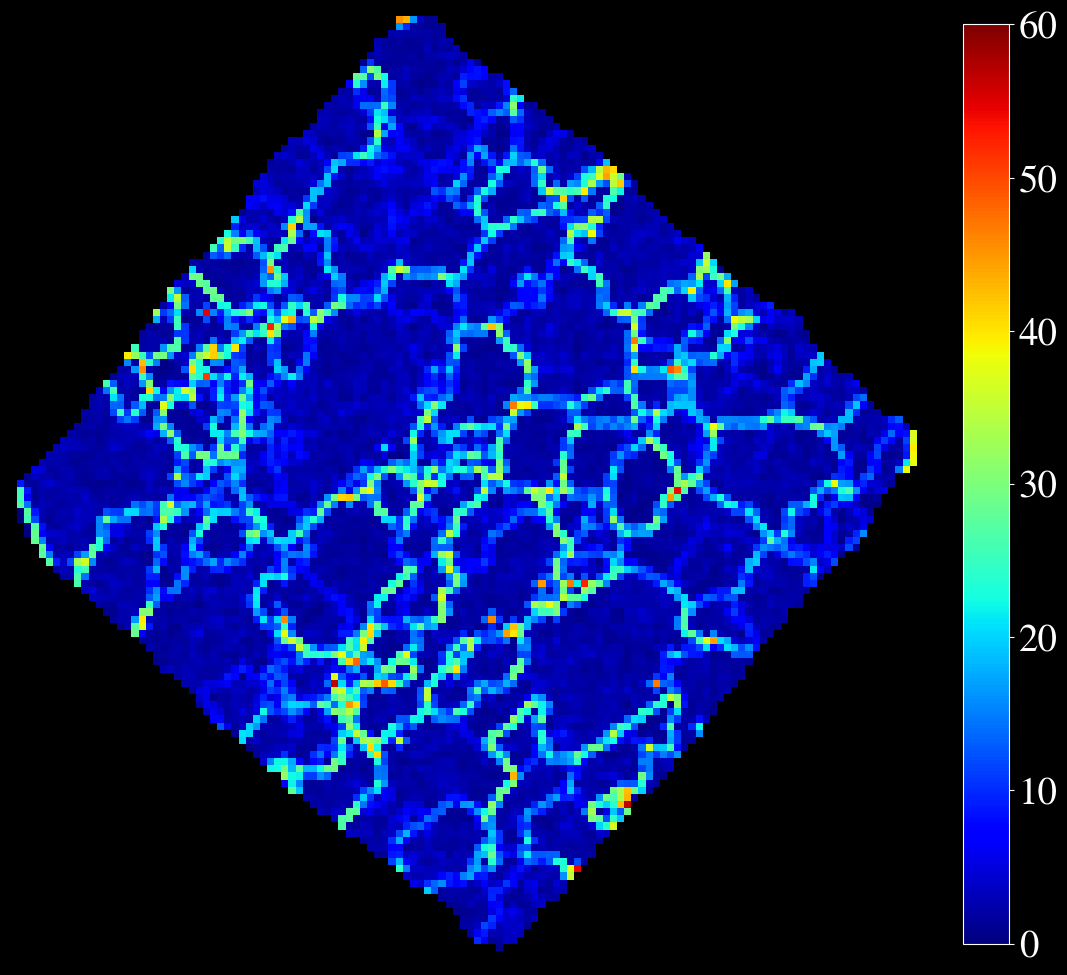

In [43]:
plt.style.use("dark_background")
fig, ax = plt.subplots(1, 1, figsize=(12, 12))
_s = kam.copy()
_s[~m] = np.nan
_s = maptools.plot.crop_to_mask(_s, m)

im = ax.imshow(_s, cmap="jet", vmin=0, vmax=60, origin="lower")
ax.invert_xaxis()

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.axis("off")
plt.show()

[ 2.09289380e+00 -7.04939686e-01  8.39341266e+02  1.07277051e+01
 -7.45095109e+00  6.09672044e+01]


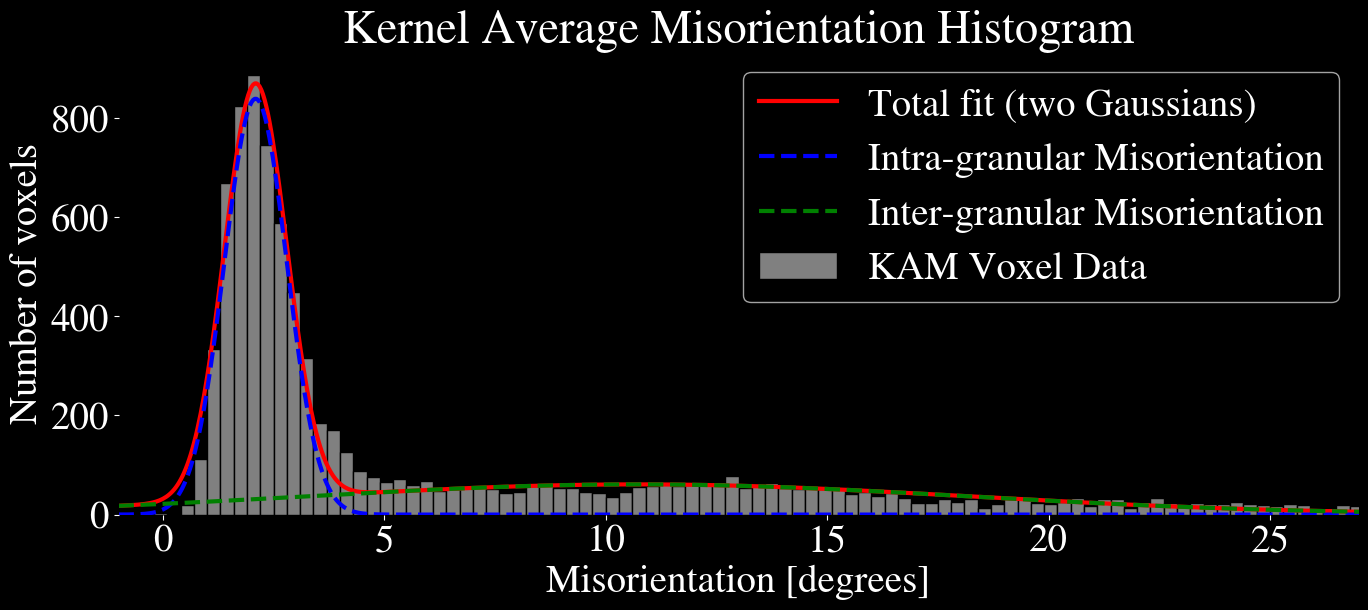

In [44]:
fig, ax = plt.subplots(1, 1, figsize=(16, 6))
data = kam[~np.isnan(kam)].flatten()
y, bins = np.histogram(data, bins=np.arange(-5, 60, 0.3))
x = (bins[:-1] + bins[1:]) / 2
# fit two gaussians to the data


def gaussian(x, mean, std, height):
    return height * np.exp(-((x - mean) ** 2) / (2 * std**2))


def lorentzian(x, mean, width, height):
    return height / (1 + ((x - mean) / width) ** 2)


def model(x, mean1, std1, height1, mean2, std2, height2):
    return gaussian(x, mean1, std1, height1) + gaussian(x, mean2, std2, height2)


left_mean = 3.0

left_amplitude = 700
left_std = 2
right_mean = 10
right_std = 5
right_amplitude = 60

inital_guess = [left_mean, left_std, 1, right_mean, right_std, 1]
fit_range = np.where(x < 35)[0]
popt, _ = curve_fit(model, x[fit_range], y[fit_range], p0=inital_guess)

xplot = np.linspace(-2, 35, 1000)

ax.plot(
    xplot,
    model(xplot, *popt),
    color="red",
    label="Total fit (two Gaussians)",
    linewidth=3,
)
ax.plot(
    xplot,
    gaussian(xplot, popt[0], popt[1], popt[2]),
    "--",
    color="blue",
    label="Intra-granular Misorientation",
    linewidth=3,
)
ax.plot(
    xplot,
    gaussian(xplot, popt[3], popt[4], popt[5]),
    "--",
    color="green",
    label="Inter-granular Misorientation",
    linewidth=3,
)

ax.hist(data, bins=bins, label="KAM Voxel Data", color="gray", edgecolor="black")
print(popt)
ax.legend()
ax.set_xlim(-1, 27)

for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_title("Kernel Average Misorientation Histogram")
ax.set_xlabel("Misorientation [degrees]")
ax.set_ylabel("Number of voxels")
plt.show()

[ 2.09289380e+00 -7.04939686e-01  8.39341266e+02  1.07277051e+01
 -7.45095109e+00  6.09672044e+01]


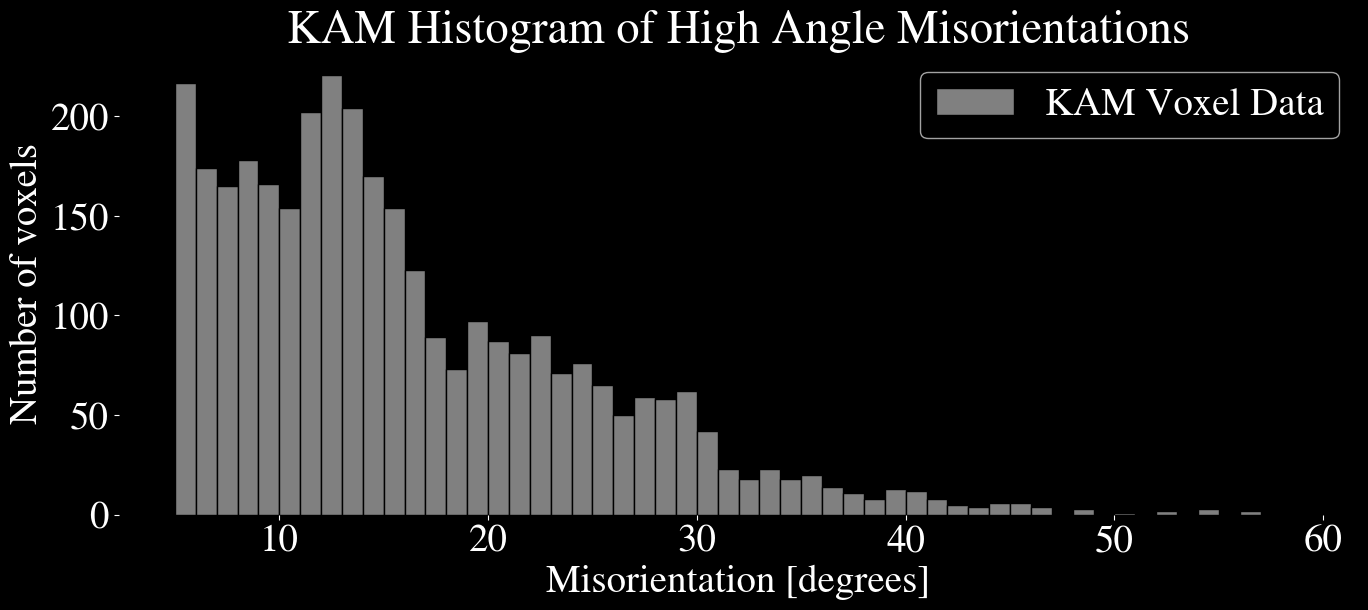

In [45]:
fig, ax = plt.subplots(1, 1, figsize=(16, 6))
data = kam[~np.isnan(kam)].flatten()
y, bins = np.histogram(data, bins=np.arange(5, 60, 1.0))
x = (bins[:-1] + bins[1:]) / 2


ax.hist(data, bins=bins, label="KAM Voxel Data", color="gray", edgecolor="black")
print(popt)
ax.legend()


for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_title("KAM Histogram of High Angle Misorientations")
ax.set_xlabel("Misorientation [degrees]")
ax.set_ylabel("Number of voxels")
plt.show()

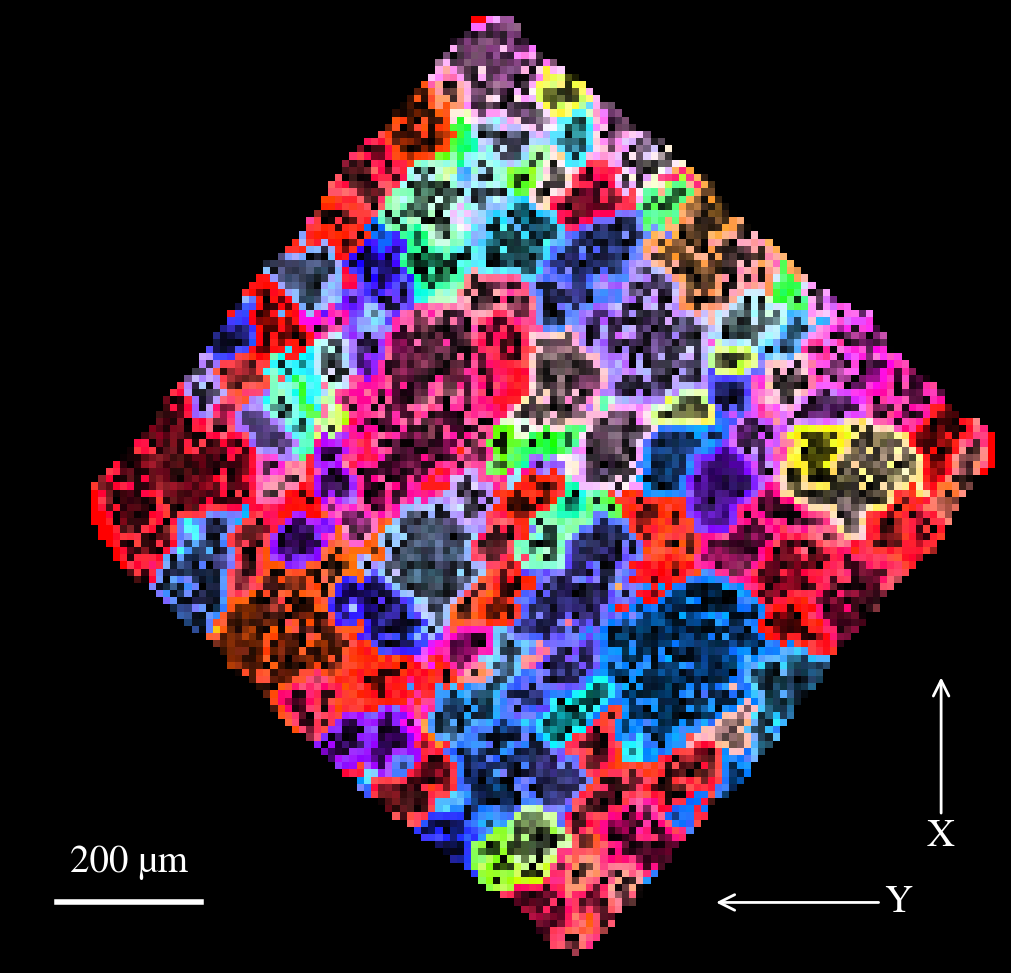

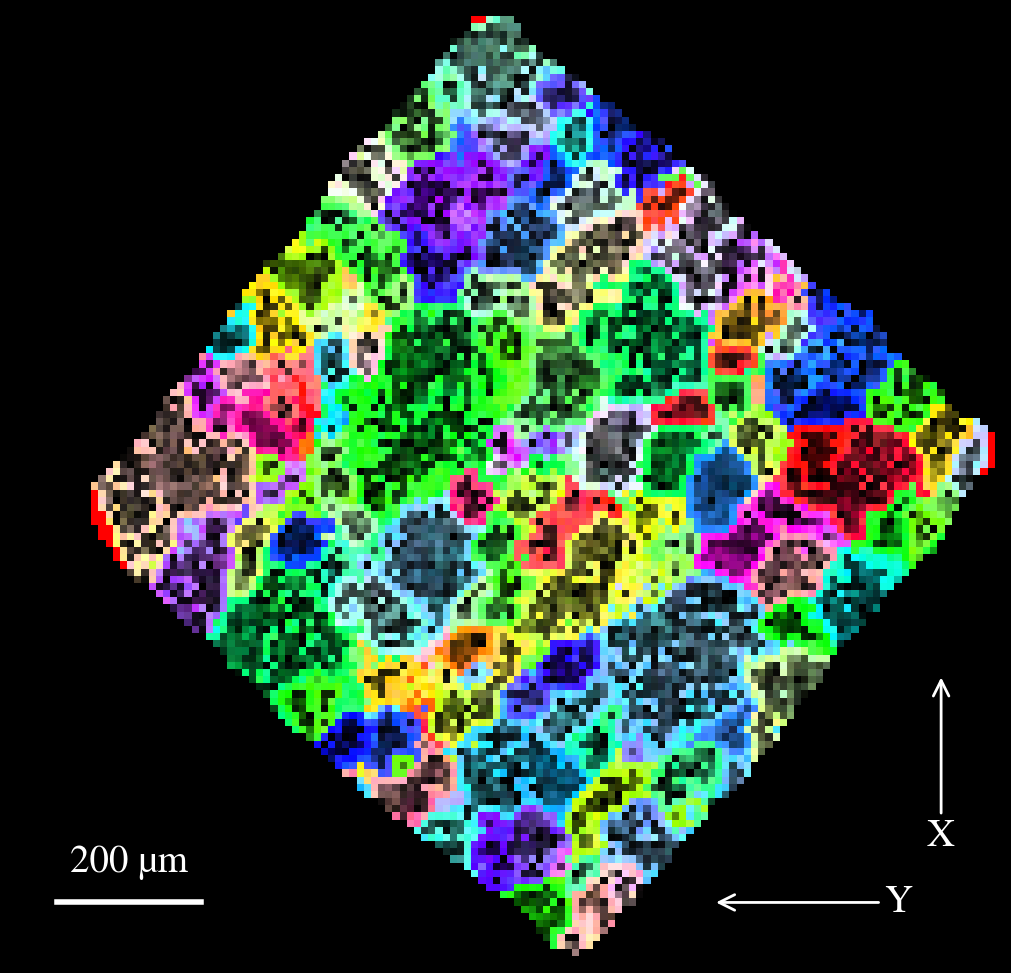

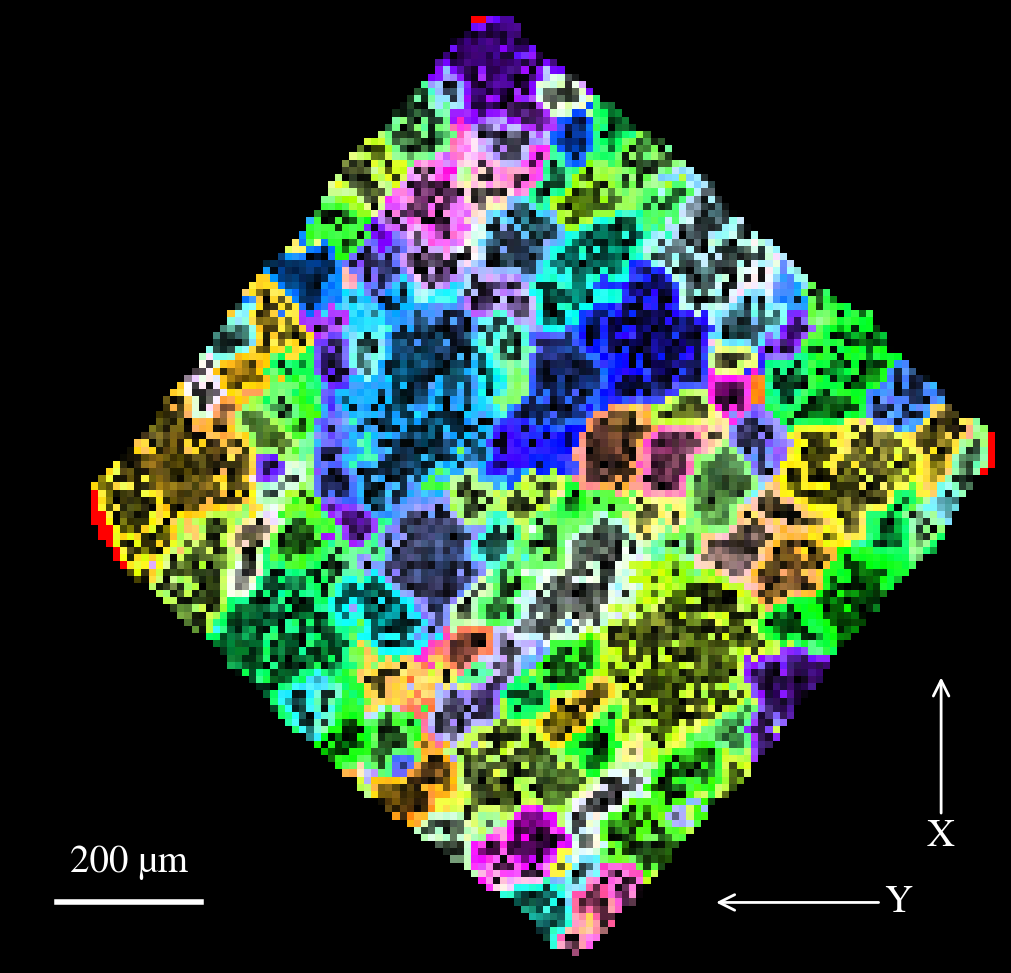

In [46]:
# plto rgb maps with kam overlaid as black

for ii in [2, 1, 0]:
    fig, axs = plt.subplots(
        1, 1, sharex=True, sharey=True, constrained_layout=True, figsize=(10, 10)
    )

    _s = rgb_filtered[:, :, 0, :, ii]

    _s_alpha = np.zeros((*_s.shape[:2], 4))
    _s_alpha[:, :, 0] = _s[:, :, 0]
    _s_alpha[:, :, 1] = _s[:, :, 1]
    _s_alpha[:, :, 2] = _s[:, :, 2]
    _s_alpha[:, :, 3] = 1 - (kam / (2.1 + 0.7))
    _s_alpha[_s_alpha[:, :, 3] > 1, 3] = 1
    _s_alpha[_s_alpha[:, :, 3] < 0, 3] = 1

    _s = _s_alpha

    _s = maptools.plot.crop_to_mask(_s, m)
    axs.imshow(_s, vmin=0, origin="lower", cmap="magma")

    axs.invert_xaxis()

    h, w = rec.shape[:2]
    axs.annotate(
        "Y",
        xy=(0.25 * w, 0.05 * h),
        xytext=(0.1 * w, 0.05 * h),
        arrowprops=dict(arrowstyle="->", color="white", lw=2),
        color="white",
        va="center",
    )
    axs.annotate(
        "X",
        xy=(0.05 * w, 0.25 * h),
        xytext=(0.05 * w, 0.1 * h),
        arrowprops=dict(arrowstyle="->", color="white", lw=2),
        color="white",
        ha="center",
    )

    px_per_um = 1 / 10
    bar_um = 200
    bar_px = bar_um * px_per_um
    x0 = 0.7 * w
    y0 = 0.05 * h
    axs.plot([x0, x0 + bar_px], [y0, y0], color="white", lw=4)
    axs.text(
        x0 + bar_px / 2,
        y0 + 0.02 * h,
        f"{bar_um} µm",
        color="white",
        ha="center",
        va="bottom",
    )

    axs.set_axis_off()


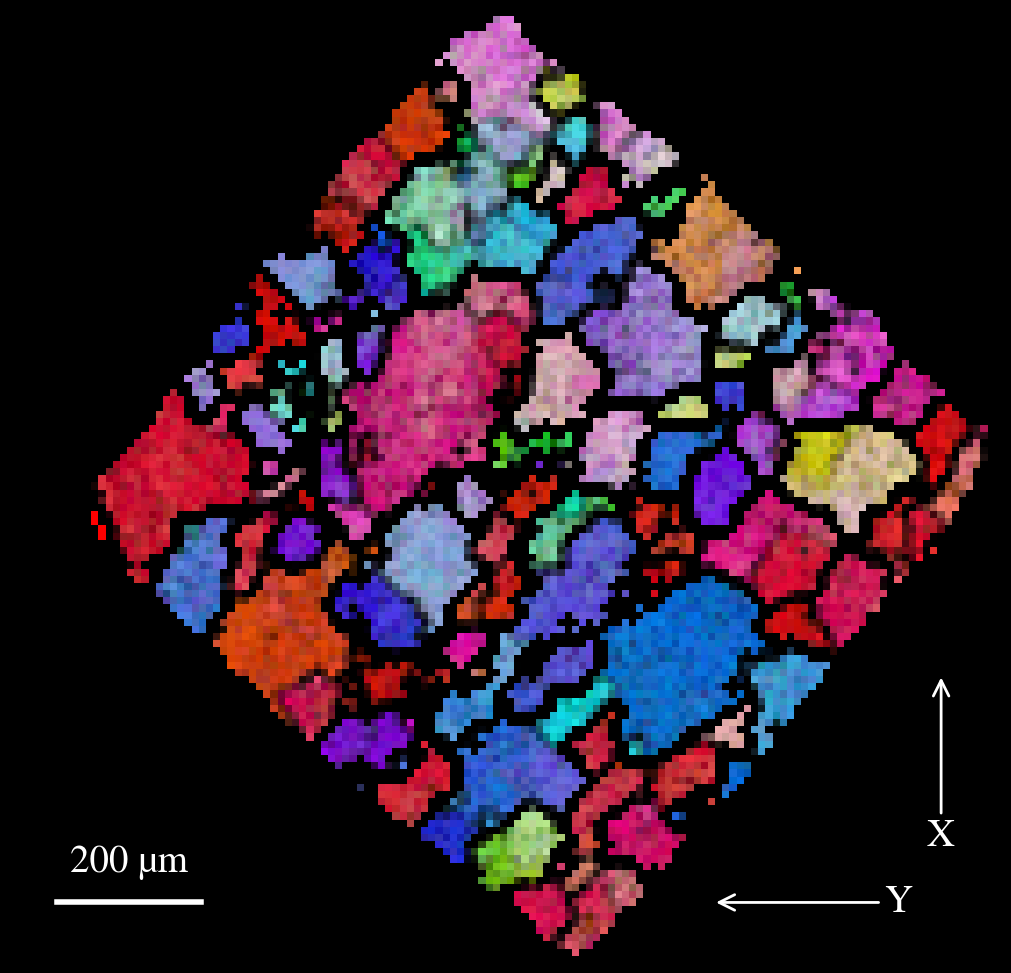

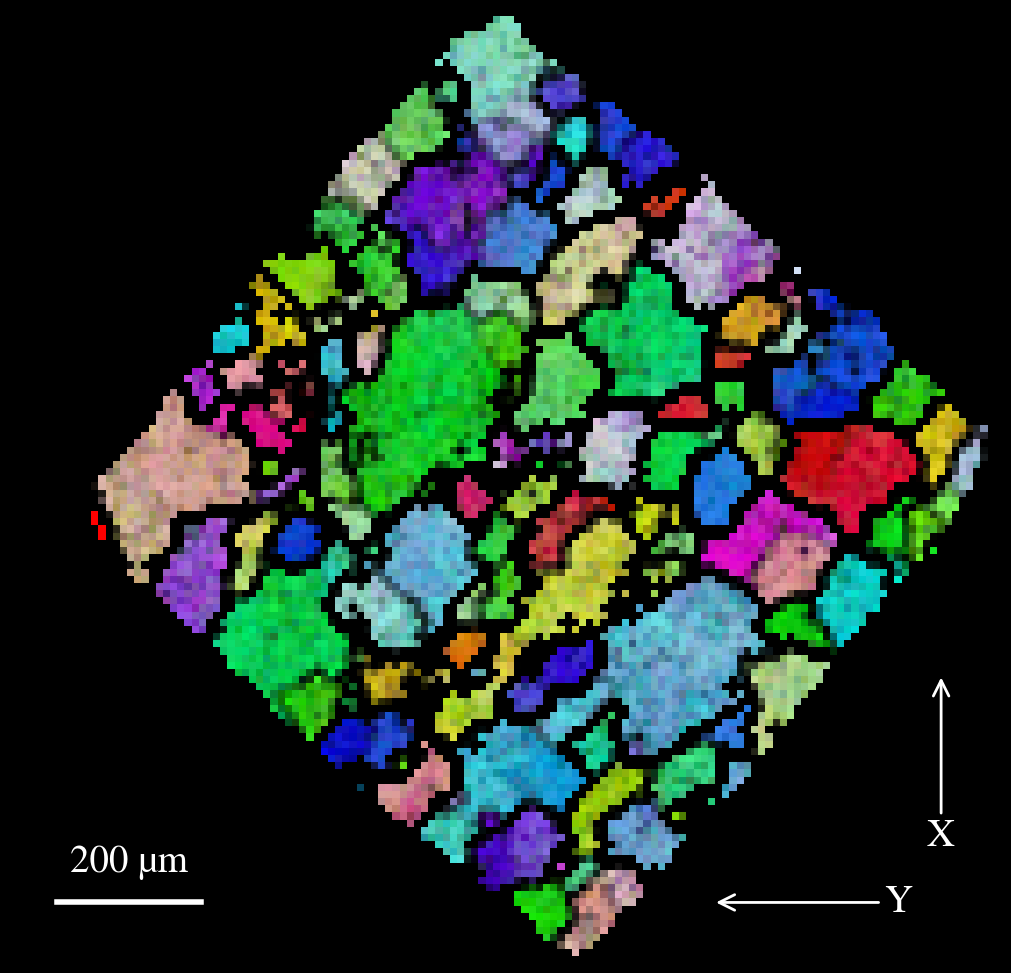

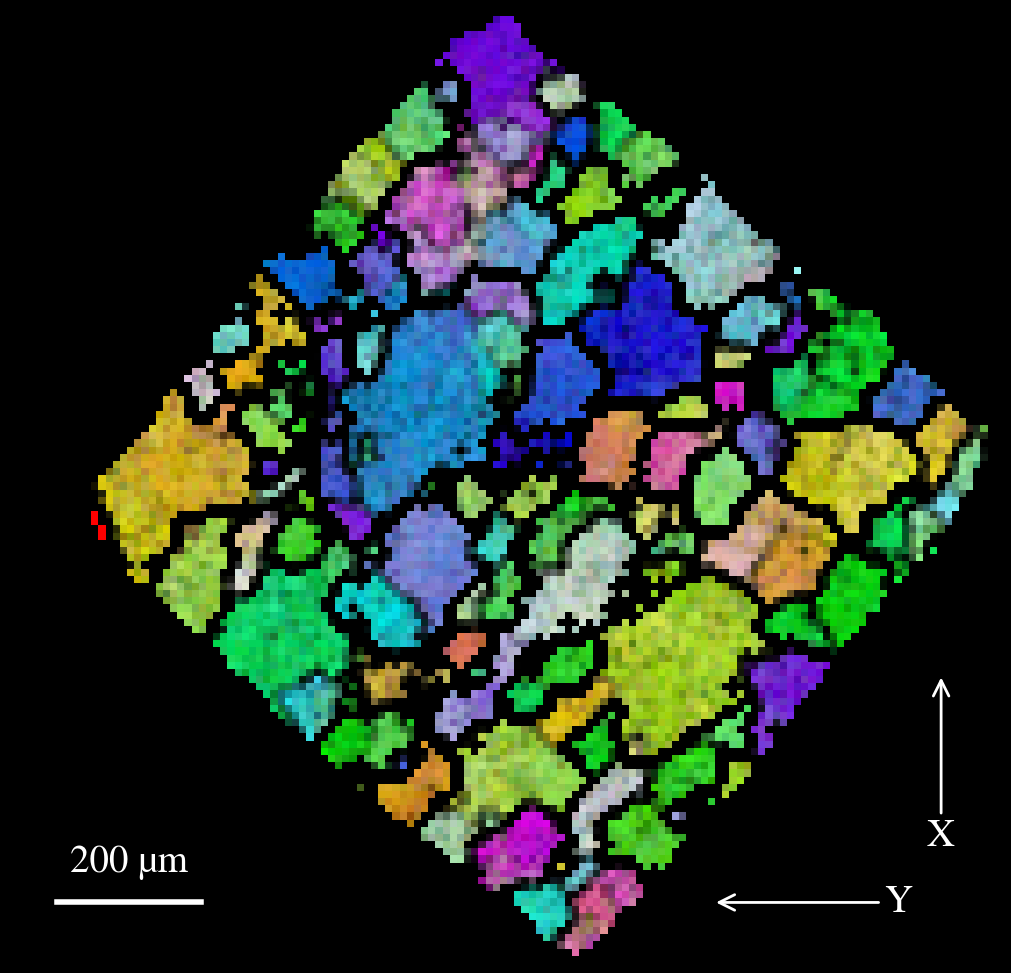

In [47]:
# plto rgb maps with kam overlaid as black

for ii in [2, 1, 0]:
    fig, axs = plt.subplots(
        1, 1, sharex=True, sharey=True, constrained_layout=True, figsize=(10, 10)
    )

    _s = rgb_filtered[:, :, 0, :, ii]

    _s_alpha = np.zeros((*_s.shape[:2], 4))
    _s_alpha[:, :, 0] = _s[:, :, 0]
    _s_alpha[:, :, 1] = _s[:, :, 1]
    _s_alpha[:, :, 2] = _s[:, :, 2]
    _s_alpha[:, :, 3] = 1 - (kam / (10))
    _s_alpha[_s_alpha[:, :, 3] > 1, 3] = 1
    _s_alpha[_s_alpha[:, :, 3] < 0, 3] = 0

    _s = _s_alpha

    _s = maptools.plot.crop_to_mask(_s, m)
    axs.imshow(_s, vmin=0, origin="lower", cmap="magma")

    axs.invert_xaxis()

    h, w = rec.shape[:2]
    axs.annotate(
        "Y",
        xy=(0.25 * w, 0.05 * h),
        xytext=(0.1 * w, 0.05 * h),
        arrowprops=dict(arrowstyle="->", color="white", lw=2),
        color="white",
        va="center",
    )
    axs.annotate(
        "X",
        xy=(0.05 * w, 0.25 * h),
        xytext=(0.05 * w, 0.1 * h),
        arrowprops=dict(arrowstyle="->", color="white", lw=2),
        color="white",
        ha="center",
    )

    px_per_um = 1 / 10
    bar_um = 200
    bar_px = bar_um * px_per_um
    x0 = 0.7 * w
    y0 = 0.05 * h
    axs.plot([x0, x0 + bar_px], [y0, y0], color="white", lw=4)
    axs.text(
        x0 + bar_px / 2,
        y0 + 0.02 * h,
        f"{bar_um} µm",
        color="white",
        ha="center",
        va="bottom",
    )

    axs.set_axis_off()

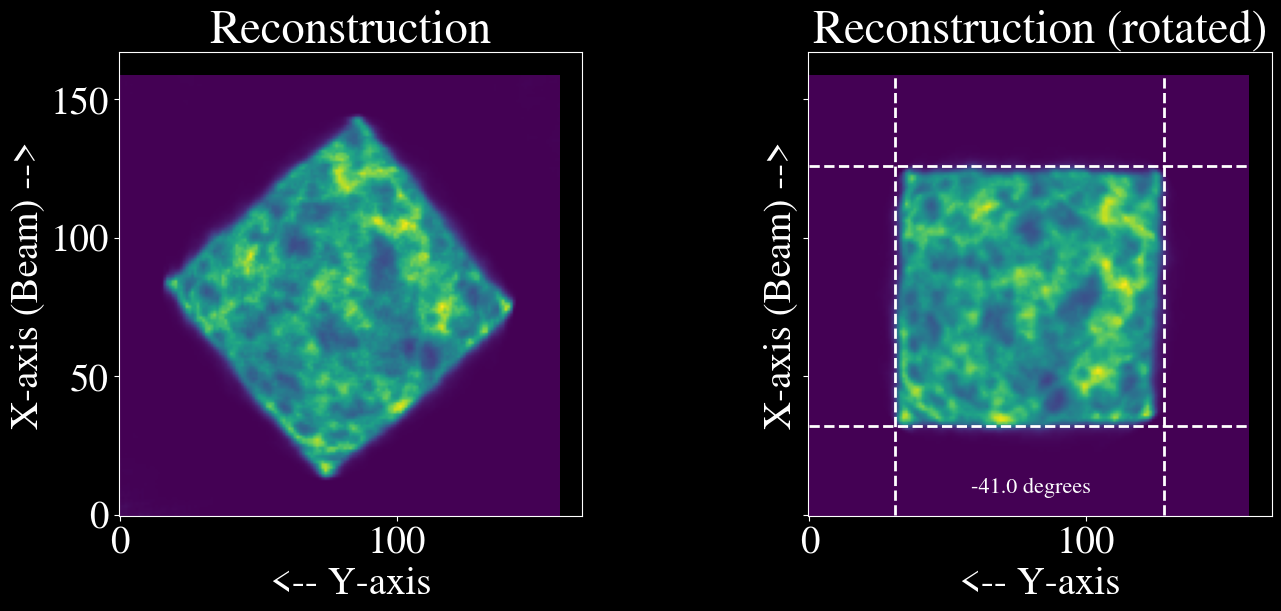

In [48]:
fig, ax = plt.subplots(
    1, 2, sharex=True, sharey=True, constrained_layout=True, figsize=(14, 6)
)

omega_alignment_degrees = -41.0

rotated_rec = rotate(rec, -omega_alignment_degrees, reshape=False, order=1)

ax[0].imshow(rec, origin="lower")
ax[0].set_title("Reconstruction")
ax[0].set_xlabel("<-- Y-axis")
ax[0].set_ylabel("X-axis (Beam) -->", x=1.1)

ax[1].imshow(rotated_rec, origin="lower")
ax[1].set_title("Reconstruction (rotated)")
ax[1].set_xlabel("<-- Y-axis")
ax[1].set_ylabel("X-axis (Beam) -->", x=1.1)
ax[1].hlines(126, 0, rec.shape[1], color="white", linewidth=2, linestyle="--")
ax[1].vlines(128, 0, rec.shape[0], color="white", linewidth=2, linestyle="--")
ax[1].hlines(32, 0, rec.shape[1], color="white", linewidth=2, linestyle="--")
ax[1].vlines(31, 0, rec.shape[0], color="white", linewidth=2, linestyle="--")
ax[1].text(
    80,
    10,
    str(omega_alignment_degrees) + " degrees",
    color="white",
    fontsize=16,
    ha="center",
    va="center",
)

plt.show()

In [49]:
import numpy as np
from orix.quaternion import Rotation, Quaternion

axis = Vector3d.zvector()

R = Rotation.from_axes_angles(axis, omega_alignment_degrees, degrees=True)

orix_orien_aligned = orix_orien * R

al1050 = Phase(space_group=225)
ipfkey = plot.IPFColorKeyTSL(al1050.point_group, direction=Vector3d.zvector())
rgb_aligned = np.asarray(ipfkey.orientation2color(orix_orien_aligned)).reshape(-1, 3)

al1050 = Phase(space_group=225)
ipfkey = plot.IPFColorKeyTSL(al1050.point_group, direction=Vector3d.zvector())
rgb = np.asarray(ipfkey.orientation2color(orix_orien)).reshape(-1, 3)


rgb_aligned - rgb


array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00, -6.66133815e-16],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       ...,
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00]])

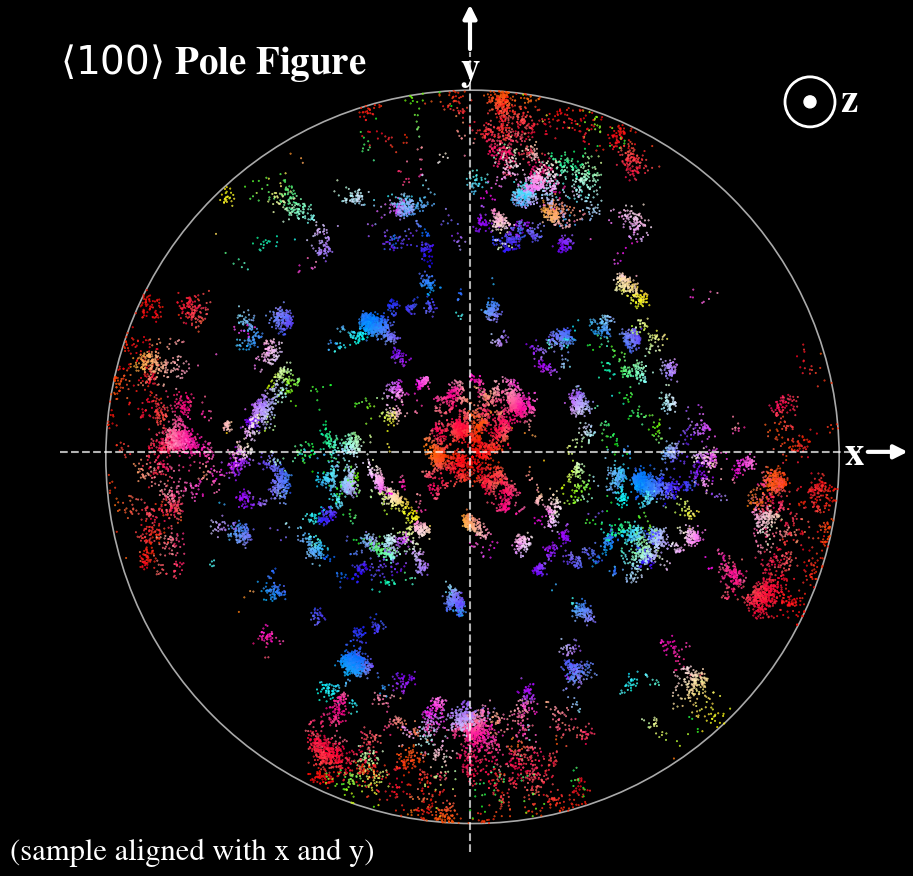

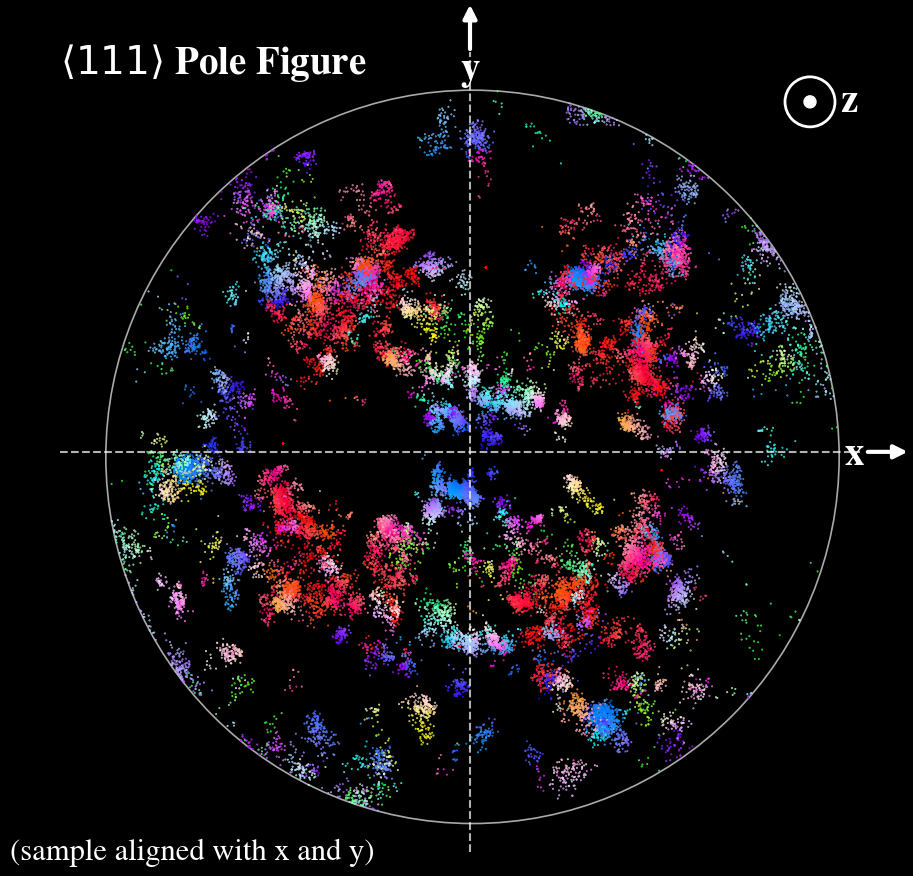

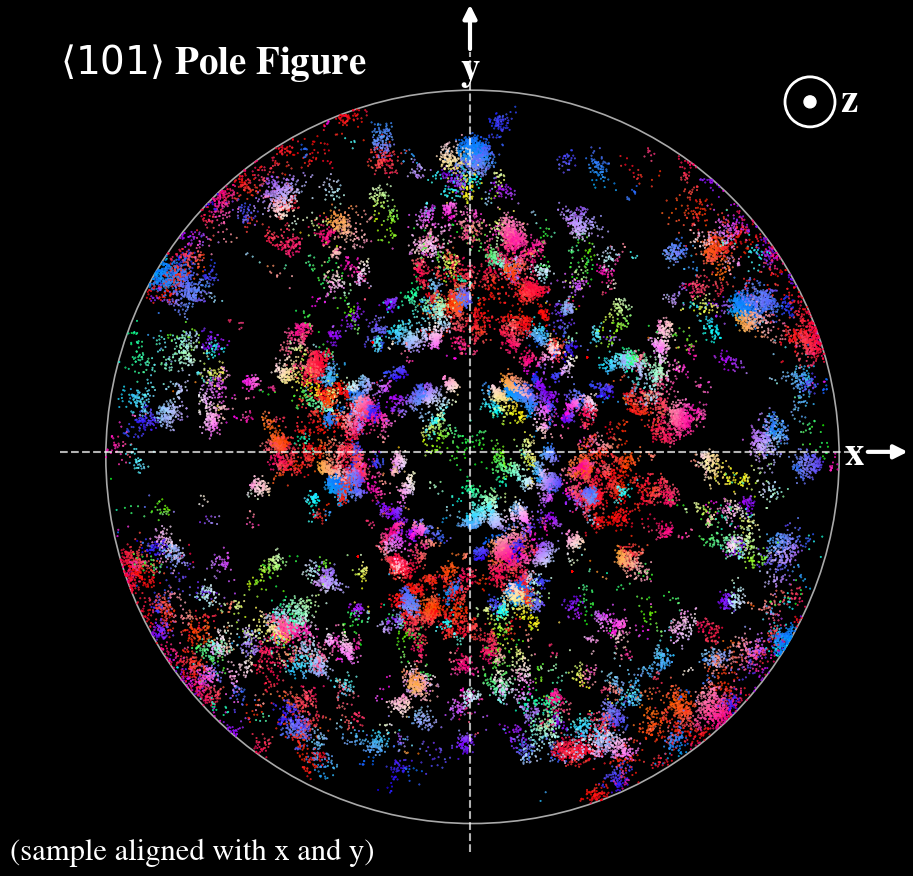

In [50]:
pole_hkls = [
    [1, 0, 0],
    [1, 1, 1],
    [1, 0, 1],
]
for hkl in pole_hkls:
    al1050 = Phase(space_group=225)
    orix_orien_aligned = orix_orien_aligned.reshape((-1,))
    orix_orien_aligned.symmetry = al1050.point_group

    ipfkey = plot.IPFColorKeyTSL(al1050.point_group, direction=Vector3d.zvector())
    rgb = np.asarray(ipfkey.orientation2color(orix_orien_aligned)).reshape(-1, 3)

    g111 = Miller(hkl=hkl, phase=al1050)
    g111_fam = g111.symmetrise(unique=True)

    poles = (~orix_orien_aligned)[:, None] * g111_fam
    poles = poles.reshape((-1,))
    mask = poles.z > 0
    poles = poles[mask]

    rgb_pf = np.repeat(rgb, g111_fam.size, axis=0)[mask]

    plt.style.use("dark_background")

    fig = poles.scatter(
        c=rgb_pf,
        s=0.2,
        grid=False,
        figure_kwargs={"figsize": (10, 10)},
        text_kwargs={"color": "white", "fontsize": 22},
        return_figure=True,
    )

    ax = plt.gca()

    for p in ax.patches:
        p.set_edgecolor("darkgray")
        p.set_linewidth(1.2)

    for l in ax.lines:
        l.set_color("white")
        l.set_linewidth(1.2)

    plt.style.use("default")
    ticksize = 24
    plt.rcParams["font.size"] = 24
    plt.rcParams["xtick.labelsize"] = ticksize
    plt.rcParams["ytick.labelsize"] = ticksize
    plt.rcParams["font.family"] = "Nimbus Roman"

    ax.tick_params(colors="white")
    for spine in ax.spines.values():
        spine.set_color("white")

    fig = plt.gcf()

    # x label + arrow
    fig.text(
        0.5,
        0.9,
        "y",
        color="white",
        fontsize=28,
        ha="left",
        va="top",
        fontweight="bold",
    )
    fig.patches.append(
        FancyArrowPatch(
            (0.51, 0.9),
            (0.51, 0.95),
            transform=fig.transFigure,
            arrowstyle="-|>",
            mutation_scale=20,
            color="white",
            linewidth=3,
        )
    )

    # y label + arrow
    fig.text(
        0.885,
        0.515,
        "x",
        color="white",
        fontsize=28,
        ha="left",
        va="top",
        fontweight="bold",
    )
    fig.patches.append(
        FancyArrowPatch(
            (0.905, 0.5),
            (0.9505, 0.5),
            transform=fig.transFigure,
            arrowstyle="-|>",
            mutation_scale=20,
            color="white",
            linewidth=3,
        )
    )

    # z out-of-plane symbol (circle + dot)
    circle = Circle(
        (0.85, 0.85),
        0.025,
        transform=fig.transFigure,
        fill=False,
        edgecolor="white",
        linewidth=2,
    )
    dot = Circle((0.85, 0.85), 0.006, transform=fig.transFigure, color="white")

    fig.patches.extend([circle, dot])
    fig.text(
        0.88, 0.85, "z", color="white", fontsize=28, va="center", fontweight="bold"
    )

    h, k, l = hkl
    hklstring = f"$\\langle {h}{k}{l} \\rangle$"
    fig.text(
        0.1,
        0.89,
        hklstring + " Pole Figure",
        color="white",
        fontsize=28,
        va="center",
        fontweight="bold",
    )

    from matplotlib.lines import Line2D

    a = 0.1
    b = 0.9

    fig.lines.append(
        Line2D(
            [0.1, 0.9],
            [0.5, 0.5],
            transform=fig.transFigure,
            color="white",
            linestyle="--",
            linewidth=1.5,
            alpha=0.7,
        )
    )

    fig.lines.append(
        Line2D(
            [0.51, 0.51],
            [0.1, 0.9],
            transform=fig.transFigure,
            color="white",
            linestyle="--",
            linewidth=1.5,
            alpha=0.7,
        )
    )
    fig.text(
        0.05,
        0.1,
        "(sample aligned with x and y)",
        color="white",
        fontsize=22,
        va="center",
    )

    plt.show()

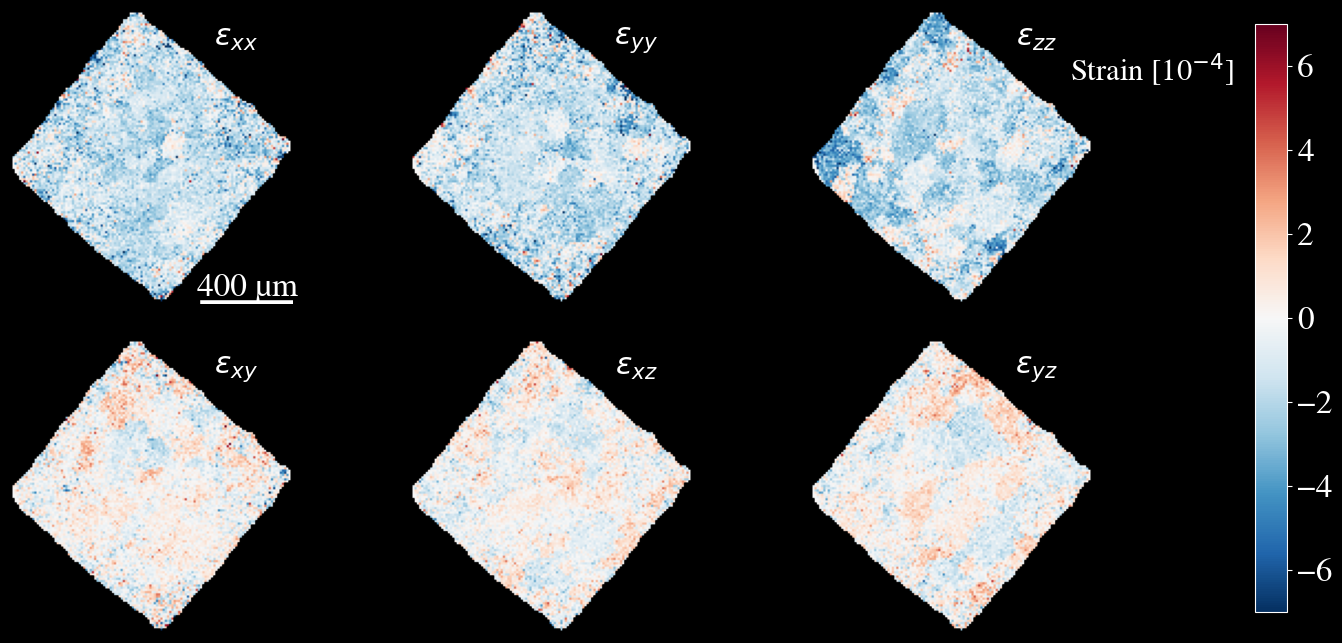

In [51]:
plt.style.use("dark_background")

fig = plt.figure(figsize=(16, 7))

x0 = [0.03, 0.28, 0.53]
y0 = [0.52, 0.05]
w = 0.30
h = 0.42

ax = np.empty((2, 3), dtype=object)
for i in range(2):
    for j in range(3):
        ax[i, j] = fig.add_axes([x0[j], y0[i], w, h])

idx = [(0, 0), (1, 1), (2, 2), (0, 1), (0, 2), (1, 2)]
titles = [
    r"$\epsilon_{xx}$",
    r"$\epsilon_{yy}$",
    r"$\epsilon_{zz}$",
    r"$\epsilon_{xy}$",
    r"$\epsilon_{xz}$",
    r"$\epsilon_{yz}$",
]

kk = 0
for i in range(2):
    for j in range(3):
        ii, jj = idx[kk]
        _s = eps_filtered[:, :, 0, ii, jj] * 1e4
        _s[~m] = np.nan
        _s = maptools.plot.crop_to_mask(_s, m)

        im = ax[i, j].imshow(_s, origin="lower", cmap="RdBu_r", vmin=-7, vmax=7)
        ax[i, j].text(
            0.8,
            0.95,
            titles[kk],
            color="white",
            fontsize=22,
            ha="center",
            va="top",
            transform=ax[i, j].transAxes,
        )

        kk += 1

        ax[i, j].invert_xaxis()

        if i == 0 and j == 0:
            px_per_um = 1 / 10
            bar_um = 400
            bar_px = bar_um * px_per_um
            x0 = 0.7 * w
            y0 = 0.05 * h
            ax[i, j].plot([x0, x0 + bar_px], [y0, y0], color="white", lw=4)
            ax[i, j].text(
                x0 + bar_px / 2,
                y0 + 0.02 * h,
                f"{bar_um} µm",
                color="white",
                ha="center",
                va="bottom",
            )
        if i == 0 and j == 2:
            ax[i, j].text(
                10,
                100,
                "Strain [10$^{-4}$]",
                color="white",
                fontsize=22,
            )

        ax[i, j].set_axis_off()

cax = fig.add_axes([0.87, 0.08, 0.02, 0.84])
fig.colorbar(im, cax=cax)

plt.show()


In [ ]:
footprint = np.ones((3, 3))
footprint[0, 0] = 0
footprint[2, 2] = 0
footprint[0, 2] = 0
footprint[2, 0] = 0

labels = maptools.properties.flood_fill(
    orientation_map,
    seed_point=(100, 100),
    footprint=footprint,
    crystal_system=7,
    local_disorientation_tolerance=2.1 + 0.7 * 3.5,
    global_disorientation_tolerance=999999999,
    mask=m,
    background_value=np.nan,
    fill_holes=True,
    max_grains=1999,
    min_grain_size=0,
    verbose=True,
)

Iteration  1 , found grain with :  412  voxels @, seed_point,  412
Iteration  2 , found grain with :  185  voxels @, seed_point,  185
Iteration  3 , found grain with :  4  voxels @, seed_point,  4
Iteration  4 , found grain with :  102  voxels @, seed_point,  102
Iteration  5 , found grain with :  202  voxels @, seed_point,  202
Iteration  6 , found grain with :  64  voxels @, seed_point,  64
Iteration  7 , found grain with :  86  voxels @, seed_point,  86
Iteration  8 , found grain with :  514  voxels @, seed_point,  514
Iteration  9 , found grain with :  5  voxels @, seed_point,  5
Iteration  10 , found grain with :  70  voxels @, seed_point,  70
Iteration  11 , found grain with :  203  voxels @, seed_point,  203
Iteration  12 , found grain with :  131  voxels @, seed_point,  131
Iteration  13 , found grain with :  1  voxels @, seed_point,  1
Iteration  14 , found grain with :  108  voxels @, seed_point,  108
Iteration  15 , found grain with :  1  voxels @, seed_point,  1
Iteration  

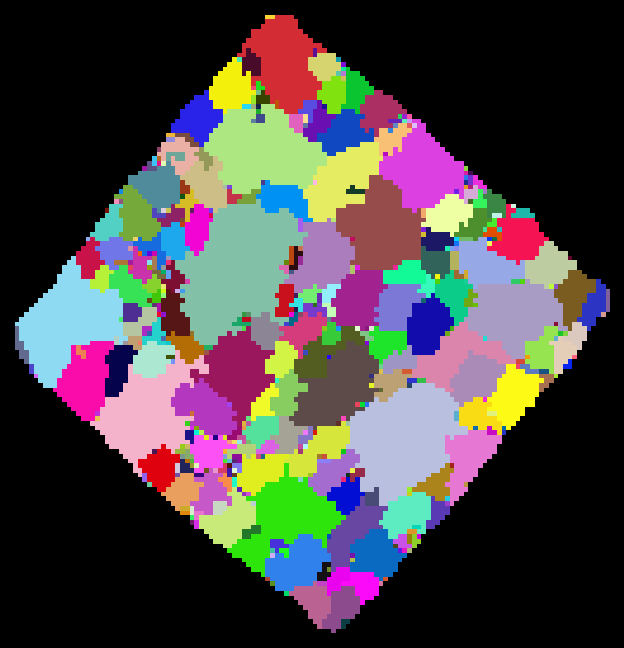

In [ ]:
rgbrandom = np.zeros((*labels.shape, 3))
grain_sizes = []
for label in np.unique(labels):
    if label == 0:
        continue
    mask = labels == label
    grain_sizes.append(np.sum(mask) * 10 * 10)
    rgbrandom[mask] = np.random.rand(3)
_s = rgbrandom.copy()
_s = maptools.plot.crop_to_mask(_s, m)

fig, ax = plt.subplots(1, 1, figsize=(7, 7))
im = ax.imshow(_s, origin="lower")
ax.invert_xaxis()
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_axis_off()
plt.tight_layout()
plt.show()

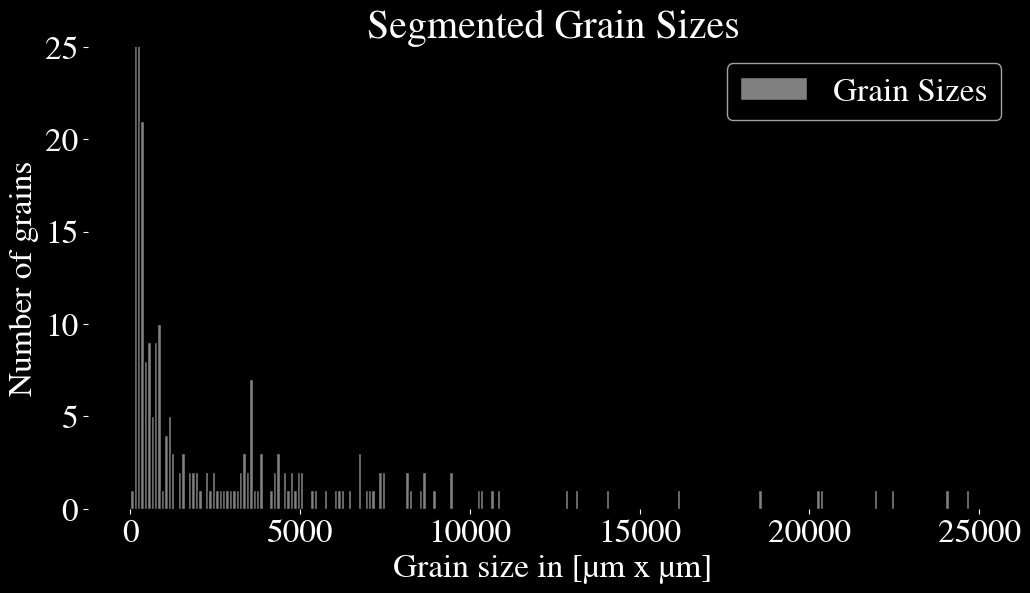

In [142]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

bins = np.arange(0, 25000, 100)

ax.hist(grain_sizes, bins, label="Grain Sizes", color="gray", edgecolor="black")
ax.legend()

for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_title("Segmented Grain Sizes")
ax.set_xlabel("Grain size in [µm x µm]")
ax.set_ylabel("Number of grains")

ax.set_ylim(0, 25)
plt.show()

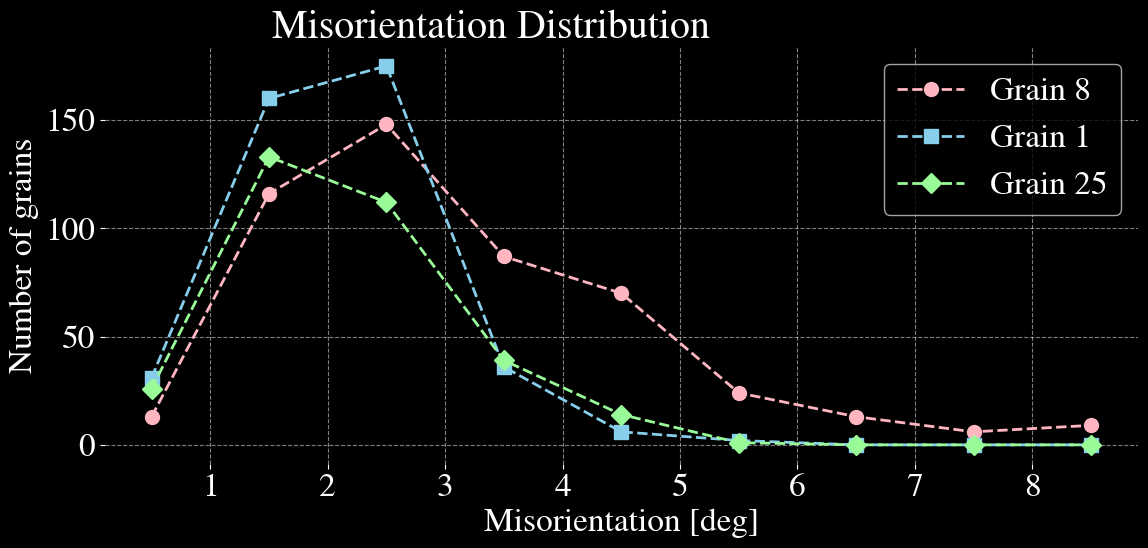

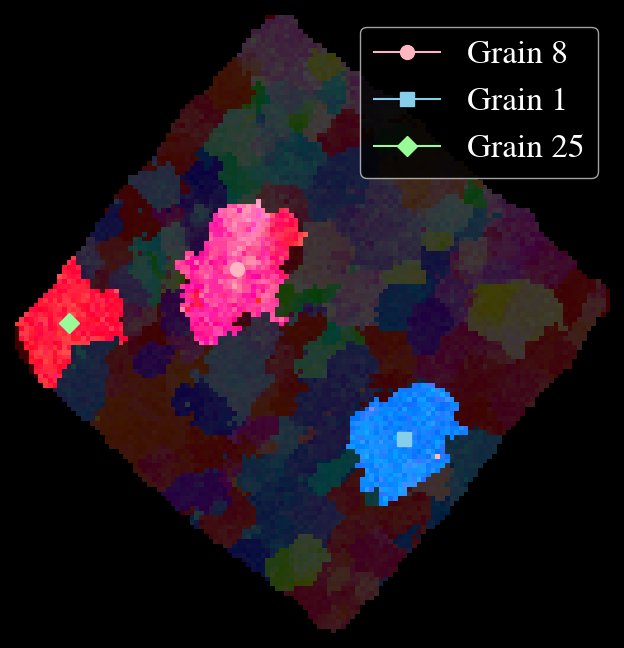

In [ ]:
idx = np.argsort(-np.array(grain_sizes))
biglab = idx[0:3] + 1

fig, ax = plt.subplots(1, 1, figsize=(12, 6))

markers = ["o", "s", "D", "P"]


from xfab.symmetry import Umis
from scipy.spatial.transform import Rotation

image = np.zeros((*rgb_filtered[:, :, 0, :, 2].shape[:2], 4))
image[:, :, 0:3] = rgb_filtered[:, :, 0, :, 2]
image[:, :, 3] = 0.25

cc = []
# pastel colors
colors = ["#FFB6C1", "#87CEEB", "#98FB98", "#DDA0DD"]
for i, lab in enumerate(biglab):
    mask = labels == lab

    u = orientation_map[mask]
    u = maptools.properties._align(u, 7)
    rot = Rotation.from_matrix(u)
    mean_rot = rot.mean()
    umean = mean_rot.as_matrix()

    # compute centorid in pixels
    _s = maptools.plot.crop_to_mask(mask, m)
    xx = np.arange(_s.shape[1])
    yy = np.arange(_s.shape[0])
    x = np.sum(_s, axis=0)
    y = np.sum(_s, axis=1)
    cx = np.sum(xx * x) / np.sum(x)
    cy = np.sum(yy * y) / np.sum(y)
    cc.append((cx, cy))

    image[mask, 3] = 1

    mis = []
    for jj in range(u.shape[0]):
        umis = Umis(u[jj], umean, 7)[:, 1].min()
        mis.append(umis)

    h, b = np.histogram(mis, bins=np.arange(0, 10, 1))
    bc = (b[:-1] + b[1:]) / 2
    ax.plot(
        bc,
        h,
        label=f"Grain {lab}",
        linestyle="--",
        lw=2,
        marker=markers[i],
        ms=10,
        c=colors[i],
    )

ax.legend()
ax.set_xlabel("KAM")
ax.set_ylabel("Number of grains")
for spine in ax.spines.values():
    spine.set_visible(False)
ax.grid(True, linestyle="--", alpha=0.5)
ax.set_title("Misorientation Distribution                          ")
ax.set_xlabel("Misorientation [deg]")
ax.set_ylabel("Number of grains")
plt.tight_layout()
plt.show()


plt.style.use("dark_background")
fig, ax = plt.subplots(1, 1, figsize=(7, 7))
_s = image.copy()
_s = maptools.plot.crop_to_mask(_s, m)
im = ax.imshow(_s, origin="lower")
ax.invert_xaxis()
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_axis_off()
for i, c in enumerate(cc):
    ax.plot(
        c[0],
        c[1],
        marker=markers[i],
        color=colors[i],
        markersize=10,
        label=f"Grain {biglab[i]}",
    )
ax.legend()
plt.tight_layout()
plt.show()


(159, 159, 40, 3, 3)

In [114]:
mean_rot

Rotation (1,)
[[ 0.934  -0.0817  0.1544 -0.3116]]